In [5]:
import sqlite3
import pandas as pd

con = sqlite3.connect("../data/processed/nhs_rtt.db")

sql = """
WITH latest AS (SELECT MAX(period_yyyymm) AS m FROM fact_rtt_monthly)
SELECT provider_org_name,
       SUM(total_waiting) AS backlog,
       ROUND(100.0 * SUM(within_18_weeks) / SUM(total_waiting), 2) AS pct_within_18
FROM fact_rtt_monthly f
JOIN latest ON f.period_yyyymm = latest.m
GROUP BY provider_org_name
HAVING SUM(total_waiting) > 5000
ORDER BY pct_within_18 ASC
LIMIT 10;
"""
pd.read_sql(sql, con)

,provider_org_name,backlog,pct_within_18
0,EAST CHESHIRE NHS TRUST,19167.0,46.09
1,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,179094.0,48.16
2,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,26641.0,48.42
3,LIVERPOOL WOMEN'S NHS FOUNDATION TRUST,14378.0,49.92
4,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,116319.0,51.14
5,EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION ...,75959.0,51.78
6,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,107775.0,52.01
7,JAMES PAGET UNIVERSITY HOSPITALS NHS FOUNDATIO...,33930.0,52.78
8,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,135559.0,52.93
9,LANCASHIRE TEACHING HOSPITALS NHS FOUNDATION T...,64049.0,53.13


In [6]:
sql = """
WITH latest AS (SELECT MAX(period_yyyymm) AS m FROM fact_rtt_monthly)
SELECT
       treatment_function_name,
       SUM(total_waiting) AS backlog,
       ROUND(100.0 * SUM(within_18_weeks) / SUM(total_waiting), 2) AS pct_within_18,
       SUM(over_52_weeks) AS over_52
FROM fact_rtt_monthly f
JOIN latest ON f.period_yyyymm = latest.m
GROUP BY treatment_function_name
ORDER BY backlog DESC
LIMIT 10;
"""

pd.read_sql(sql, con)

,treatment_function_name,backlog,pct_within_18,over_52
0,Trauma and Orthopaedic Service,853046.0,58.22,25716.0
1,Other - Medical Services,621799.0,66.05,7075.0
2,Ophthalmology Service,603289.0,70.19,5012.0
3,Ear Nose and Throat Service,591034.0,52.45,16212.0
4,Gynaecology Service,572008.0,57.26,15273.0
5,Other - Surgical Services,481435.0,62.37,9186.0
6,Dermatology Service,405659.0,59.85,7092.0
7,Urology Service,391331.0,62.84,8074.0
8,Cardiology Service,388079.0,63.20,5029.0
9,General Surgery Service,386066.0,60.06,9228.0


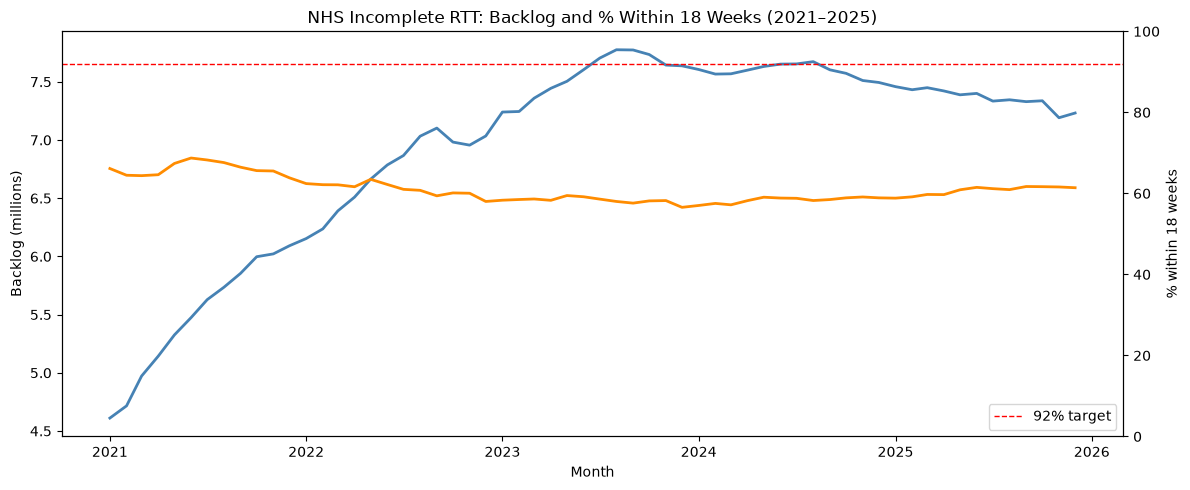

   period_yyyymm    backlog  pct_within_18  pct_over_52  gap_vs_92     period
54       2025-07  7334286.0          61.17         2.63      30.83 2025-07-01
55       2025-08  7345544.0          60.93         2.61      31.07 2025-08-01
56       2025-09  7329574.0          61.70         2.48      30.30 2025-09-01
57       2025-10  7337076.0          61.66         2.38      30.34 2025-10-01
58       2025-11  7191310.0          61.59         2.19      30.41 2025-11-01
59       2025-12  7231880.0          61.40         1.97      30.60 2025-12-01

Latest gap vs 92% target: 30.6 points


In [7]:
import matplotlib.pyplot as plt

con = sqlite3.connect("../data/processed/nhs_rtt.db")

sql = """
SELECT
  period_yyyymm,
  SUM(total_waiting) AS backlog,
  ROUND(100.0 * SUM(within_18_weeks) / SUM(total_waiting), 2) AS pct_within_18,
  ROUND(100.0 * SUM(over_52_weeks) / SUM(total_waiting), 2) AS pct_over_52,
  ROUND(92.0 - (100.0 * SUM(within_18_weeks) / SUM(total_waiting)), 2) AS gap_vs_92
FROM fact_rtt_monthly
GROUP BY period_yyyymm
ORDER BY period_yyyymm;
"""

national = pd.read_sql(sql, con)
national["period"] = pd.to_datetime(national["period_yyyymm"] + "-01")

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(national["period"], national["backlog"] / 1e6, color="steelblue", linewidth=2)
ax1.set_ylabel("Backlog (millions)")
ax1.set_xlabel("Month")
ax1.set_title("NHS Incomplete RTT: Backlog and % Within 18 Weeks (2021–2025)")

ax2 = ax1.twinx()
ax2.plot(national["period"], national["pct_within_18"], color="darkorange", linewidth=2)
ax2.axhline(92, color="red", linestyle="--", linewidth=1, label="92% target")
ax2.set_ylabel("% within 18 weeks")
ax2.set_ylim(0, 100)
ax2.legend(loc="lower right")

fig.tight_layout()
plt.show()

print(national.tail(6))
print("\nLatest gap vs 92% target:", national.iloc[-1]["gap_vs_92"], "points")